# Project 2 — Pricing, Discount & Profit Leakage Analysis

## Executive Summary

- Discounting is the primary driver of profit leakage, not volume shortfall.
- Discounts above **20%** are consistently value-destructive across all segments.
- High-discount transactions (≥20%) account for a **meaningful share of revenue (~15%)**
  but destroy a **disproportionate share of total profit (~50%+)**.
- A relatively small number of **“bad deals”** (high discount + negative profit)
  are responsible for nearly half of total profit loss.
- Losses are **concentrated**, not widespread — a handful of subcategories
  (e.g., Tables, Bookcases, Supplies) explain most profit destruction.
- Profit recovery does not require broad price increases, but **targeted pricing
  controls and discount caps** on clearly identified failure zones.

## Objective

Identify profit leakage driven by discounting practices, loss-making deals,
and structurally weak pricing across segments and subcategories,
and translate findings into clear pricing control actions.

## Business Questions

- How does discounting impact profitability?
- Which discounts and subcategories destroy value?
- Where should discounting be restricted or redesigned?

In [1]:
#Setup — mount Drive, connect to superstore.db, load tables into pandas

from google.colab import drive
drive.mount('/content/drive')

import sqlite3
import pandas as pd
import numpy as np

con = sqlite3.connect("/content/drive/MyDrive/superstore.db")
print("Connected!")

orders = pd.read_sql_query("SELECT * FROM orders;", con)
returns = pd.read_sql_query("SELECT * FROM returns;", con)
managers = pd.read_sql_query("SELECT * FROM managers;", con)

print("Loaded:", orders.shape, returns.shape, managers.shape)

Mounted at /content/drive
Connected!
Loaded: (9994, 20) (296, 5) (4, 2)


## Dataset Overview

- **orders** — Line-item level sales data including price, discount, quantity, profit,
  customer, product, segment, region, and dates.
- **returns** — Order-level return flags (used only for cross-checks, not primary in this project).
- **managers** — Region → manager mapping (optional, for ownership context).

This project primarily operates at the **line-item level**, as pricing and discounting
decisions are applied per product per order line.

## Data Grain & Modeling

- Primary grain: **Line-item level (orders table)**
- Each row represents a priced transaction with an explicit discount applied
- Profit is evaluated directly at the transaction level
- Aggregations are performed selectively by:
  - Discount bucket
  - Subcategory
  - Segment

Unlike Project 1, no order-level or customer-level base table is constructed upfront,
as discount impact is best analyzed at the transactional level.

## Data Preparation & Validation

### Why this step exists

Before analyzing discount behavior and profit leakage, we validate that
discount, sales, and profit fields are consistent and interpretable.

This ensures that observed losses are driven by pricing behavior,
not data quality issues.

## Data Validation & Sanity Checks

Before analyzing discount-driven profit leakage, we validate the integrity
and distribution of key financial variables.

### Checks Performed

- Distribution of **sales**, **profit**, **discount**, and **quantity**
- Identification of negative profit observations
- Range and concentration of discount values
- Confirmation that no missing or anomalous values distort analysis

This ensures that downstream pricing insights are driven by
real data behavior rather than data quality artifacts.

In [2]:
# Basic data sanity checks for pricing analysis

orders[["sales", "profit", "discount", "quantity"]].describe()

,sales,profit,discount,quantity
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,0.156203,3.789574
std,623.245101,234.260108,0.206452,2.225110
min,0.444000,-6599.978000,0.000000,1.000000
25%,17.280000,1.728750,0.000000,2.000000
50%,54.490000,8.666500,0.200000,3.000000
75%,209.940000,29.364000,0.200000,5.000000
max,22638.480000,8399.976000,0.800000,14.000000


# Q1. Discount vs Profit — Is Discounting Actually Helping?

## Business Question

What is the relationship between discount levels and profitability?

Specifically:
- Does higher discount always reduce profit?
- Is the impact linear, or does profitability collapse beyond certain discount levels?

## Why this matters

Discounting is often used to drive volume, but excessive or poorly targeted discounts
can destroy margin without meaningful sales uplift.

Before defining rules or buckets, we first need to understand the *raw relationship*
between discount and profit at the transaction level.

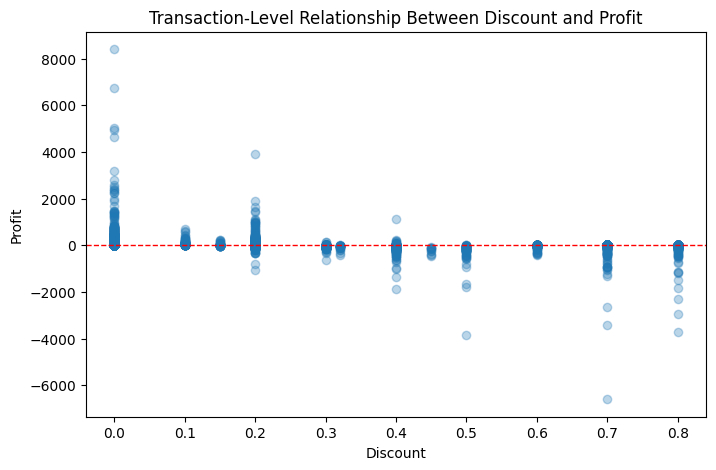

In [3]:
# Q1 — Discount vs Profit (transaction-level)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(
    orders["discount"],
    orders["profit"],
    alpha=0.3
)

plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Transaction-Level Relationship Between Discount and Profit")
plt.show()

### Insight — Discount vs Profit

The relationship between discount and profit is clearly **non-linear**.

- At **low discounts (0–20%)**, profits are volatile but mostly positive.
- Beyond **~30% discount**, loss-making transactions become frequent and severe.
- Extremely high discounts (≥60%) are almost exclusively associated with large losses.

**Conclusion:**  
Discounting does not scale profitably. There appears to be a structural break beyond which
additional discounting destroys margin rather than driving profitable volume.

# Q2. Profit Margin by Discount Bucket

## Business Question

How does profitability change across different discount levels?

Rather than looking at individual transactions, we group discounts into buckets
to understand how margins behave as discount intensity increases.

## Discount Buckets Used

- 0%
- 0–10%
- 10–20%
- 20–30%
- 30%+

In [27]:
conditions = [
    orders["discount"] == 0,
    (orders["discount"] > 0) & (orders["discount"] <= 0.10),
    (orders["discount"] > 0.10) & (orders["discount"] <= 0.20),
    (orders["discount"] > 0.20) & (orders["discount"] <= 0.30),
    orders["discount"] > 0.30
]

choices = [
    "0%",
    "0–10%",
    "10–20%",
    "20–30%",
    "30%+"
]

orders["discount_bucket"] = np.select(conditions, choices, default="Unknown")

discount_metrics = orders.groupby('discount_bucket').agg(
    total_sales = ('sales','sum'),
    total_profit = ('profit','sum'),
).reset_index()

discount_metrics['profit_margin'] = round(discount_metrics['total_profit'] / discount_metrics['total_sales'],2)

discount_metrics = discount_metrics.sort_values(
    by="discount_bucket",
    key=lambda x: x.map({
        "0%": 0,
        "0–10%": 1,
        "10–20%": 2,
        "20–30%": 3,
        "30%+": 4
    })
)

discount_metrics

,discount_bucket,total_sales,total_profit,profit_margin
0,0%,1.087908e+06,320987.6032,0.30
1,0–10%,5.436935e+04,9029.1770,0.17
2,10–20%,7.921529e+05,91756.2975,0.12
3,20–30%,1.032267e+05,-10369.2774,-0.10
4,30%+,2.595435e+05,-125006.7786,-0.48


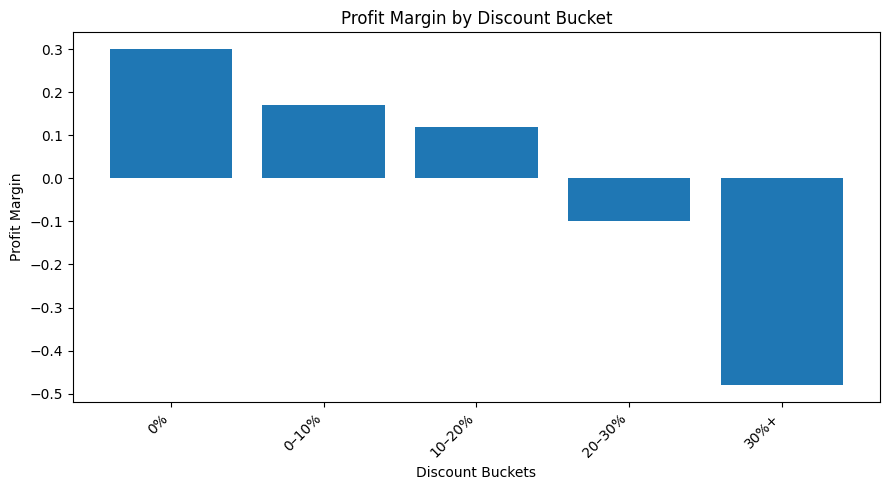

In [5]:

plt.figure(figsize=(9,5))
plt.bar(discount_metrics['discount_bucket'], discount_metrics['profit_margin'])
plt.xticks(rotation=45, ha="right")
plt.title("Profit Margin by Discount Bucket")
plt.ylabel("Profit Margin")
plt.xlabel("Discount Buckets")
plt.tight_layout()
plt.show()

### Insight — Discounting Has a Non-Linear Profit Impact

Profit margins decline sharply as discounts increase.

- Orders with **no discount** deliver ~30% margins.
- Margins compress steadily up to the **10–20%** bucket.
- At **≥20% discount**, profitability turns negative.
- **30%+ discounts destroy value**, generating losses despite meaningful revenue.

**Conclusion:** High discounts are not a volume lever — they are a profit leak.

## Q3. Revenue & Profit Exposure in High-Discount Buckets

### Business Question

How much **revenue** and **profit (or loss)** comes from **high-discount transactions**?

Specifically:
- What percentage of total sales comes from discounts **≥20%**?
- What percentage of total profit (or loss) is driven by these discounts?

### Why this matters

High discounts are only problematic if they impact **material revenue or profitability**.

This analysis:
- Quantifies the **true scale of discount-driven profit leakage**
- Distinguishes between:
  - Small, contained losses
  - Structural pricing issues that threaten overall profitability

If a meaningful share of revenue sits in loss-making discount buckets, pricing control becomes a **strategic necessity**, not a tactical optimization.

### Approach

- Use the previously created **discount buckets**
- Focus on high-discount ranges:
  - `20–30%`
  - `30%+`
- Measure:
  - Share of total sales
  - Share of total profit (or loss)
- Express results as **percentages of overall business performance**

In [20]:
# Totals
overall_sales = orders["sales"].sum()
overall_profit = orders["profit"].sum()

# Total LOSS in the whole dataset (absolute, positive number)
total_loss_abs = (-orders.loc[orders["profit"] < 0, "profit"]).sum()

# High discount buckets table (already created by you)
high_discount_buckets = discount_metrics.loc[
    discount_metrics["discount_bucket"].isin(["20–30%", "30%+"])
].copy()

# % of total sales (good)
high_discount_buckets["pct_of_total_sales"] = round(
    high_discount_buckets["total_sales"] * 100 / overall_sales, 2
)

# Convert bucket profit into "loss" only when profit is negative
high_discount_buckets["loss_abs"] = (-high_discount_buckets["total_profit"]).clip(lower=0)

# % of total losses (best leakage metric; always positive)
high_discount_buckets["pct_of_total_losses"] = np.where(
    total_loss_abs > 0,
    round(high_discount_buckets["loss_abs"] * 100 / total_loss_abs, 2),
    0
)

# profit drag vs overall profit (positive %)
high_discount_buckets["pct_profit_drag_vs_overall_profit"] = np.where(
    overall_profit > 0,
    round(high_discount_buckets["loss_abs"] * 100 / overall_profit, 2),
    0
)

high_discount_buckets

,discount_bucket,total_sales,total_profit,profit_margin,pct_of_total_sales,loss_abs,pct_of_total_losses,pct_profit_drag_vs_overall_profit
3,20–30%,103226.6550,-10369.2774,-0.10,4.49,10369.2774,6.64,3.62
4,30%+,259543.4948,-125006.7786,-0.48,11.30,125006.7786,80.07,43.65


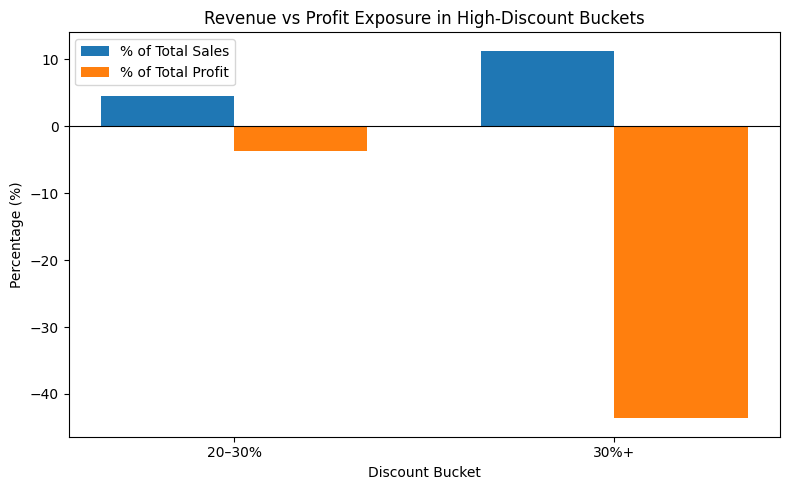

In [7]:
buckets = high_discount_buckets["discount_bucket"]
sales_pct = high_discount_buckets["pct_of_total_sales"]
profit_pct = high_discount_buckets["pct_of_total_profit"]

x = np.arange(len(buckets))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, sales_pct, width, label="% of Total Sales")
plt.bar(x + width/2, profit_pct, width, label="% of Total Profit")

plt.xticks(x, buckets)
plt.axhline(0, color="black", linewidth=0.8)

plt.title("Revenue vs Profit Exposure in High-Discount Buckets")
plt.ylabel("Percentage (%)")
plt.xlabel("Discount Bucket")
plt.legend()

plt.tight_layout()
plt.show()

## Key Insights

- Discounts of 20% and above account for a material share of total revenue (~16%).
- High-discount buckets generate disproportionate losses relative to their revenue contribution.
- The 30%+ discount bucket alone drives more than 40% of total profit destruction.
- Profit margins turn consistently negative beyond the 20% discount threshold.
- Deep discounting does not generate enough incremental volume to offset margin erosion.

## Business Interpretation

- Revenue generated at high discounts is low-quality revenue.
- Discounts above ~20% act as a value-destroying lever rather than a growth lever.
- Enforcing discount discipline can improve profitability without increasing sales volume or acquisition costs.

## Implication for Next Analysis

- Identify subcategories where high discounts are structurally embedded.
- Isolate loss-making transactions caused by excessive discounting.
- Design discount guardrails instead of relying on blanket discounting.

## Q4. Structurally Loss-Making Subcategories

### Business Question

Which product subcategories are structurally loss-making after discounts?

### Why this matters

Some subcategories destroy value not because of execution errors, but due to
systematic pricing weaknesses amplified by discounting.

Identifying these subcategories helps distinguish:
- Tactical discount misuse
- From structural pricing failure

This directly informs pricing resets, discount caps, or product rationalization.

### Approach

- Analyze data at the **line-item level** to correctly attribute profit and loss
- Aggregate sales and profit by **subcategory**
- Rank subcategories by total profit
- Highlight:
  - Negative profit subcategories
  - Low-margin subcategories with meaningful revenue

In [8]:
subcategory_metrics = (
    orders
    .groupby("subcategory")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        avg_discount = ('discount','mean')
    )
    .reset_index()
)

subcategory_metrics["profit_margin"] = (
    subcategory_metrics["total_profit"] / subcategory_metrics["total_sales"]
)

# Loss-making subcategories
loss_subcats = subcategory_metrics[
    subcategory_metrics["total_profit"] < 0
].sort_values("total_profit")


loss_subcats

,subcategory,total_sales,total_profit,avg_discount,profit_margin
16,Tables,206965.5320,-17725.4811,0.261285,-0.085645
4,Bookcases,114879.9963,-3472.5560,0.211140,-0.030228
15,Supplies,46673.5380,-1189.0995,0.076842,-0.025477


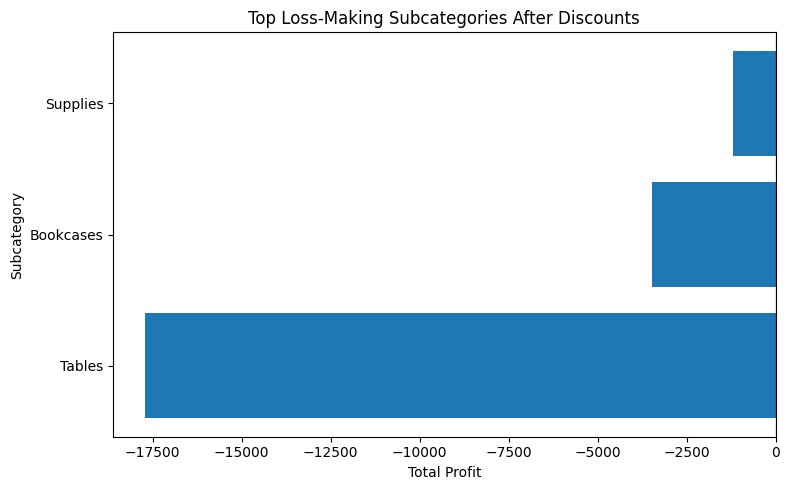

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(
    loss_subcats["subcategory"],
    loss_subcats["total_profit"]
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top Loss-Making Subcategories After Discounts")
plt.xlabel("Total Profit")
plt.ylabel("Subcategory")
plt.tight_layout()
plt.show()

### Key Insight

Profit leakage at the subcategory level is **highly concentrated**, not widespread.

Only **three subcategories** are structurally loss-making after discounts:

- **Tables** — the single largest loss driver, responsible for the majority of subcategory-level losses  
- **Bookcases** — consistently negative profitability with moderate discounting  
- **Supplies** — low-margin category pushed into losses despite relatively lower average discounts  

Notably:
- Losses are **not driven by uniform discounting across all products**
- A small number of subcategories account for **disproportionate profit destruction**
- This indicates **pricing structure issues**, not isolated transactional noise

**Implication:**  
Targeted pricing controls at the **subcategory level** (especially Tables) will deliver far higher impact than blanket discount tightening across the entire catalog.

**Note**

At this stage, the analysis identifies **structurally loss-making subcategories** but does not yet assign causality.

Discount impact is evaluated in subsequent steps by layering:
- average discount exposure (Q5)
- volume response to discounting (Q7)

This sequencing ensures that pricing recommendations are **evidence-based**, not assumption-driven.

## Q5. Segment-Level Discount Dependence

### Business Question

Which customer segments rely most heavily on high discounting, and how does profitability behave at those discount levels?

### Why this matters

Not all discounting is equal.

- Some segments may require discounts to drive volume
- Others may be over-discounted by habit, not necessity
- Segment-level analysis helps answer:
  - Where pricing flexibility is justified
  - Where discounting is structurally dangerous

This prevents blanket discount policies and supports segment-specific pricing controls.

In [10]:
segment_discount = orders.groupby(['segment','discount_bucket']).agg(
    total_sales = ('sales','sum'),
    total_profit = ('profit','sum')
).reset_index()

segment_high_discount = segment_discount.loc[(
    segment_discount['discount_bucket'] == '20–30%') |
     (segment_discount['discount_bucket'] == '30%+')].copy()

segment_high_discount['profit_margin'] = round(segment_high_discount['total_profit'] / segment_high_discount['total_sales'],2)
segment_high_discount.sort_values(by='total_profit')

,segment,discount_bucket,total_sales,total_profit,profit_margin
4,Consumer,30%+,126066.8400,-65551.7464,-0.52
9,Corporate,30%+,76417.4253,-37227.4873,-0.49
14,Home Office,30%+,57059.2295,-22227.5449,-0.39
3,Consumer,20–30%,63155.8550,-6338.4144,-0.10
8,Corporate,20–30%,22955.4570,-2543.2759,-0.11
13,Home Office,20–30%,17115.3430,-1487.5871,-0.09


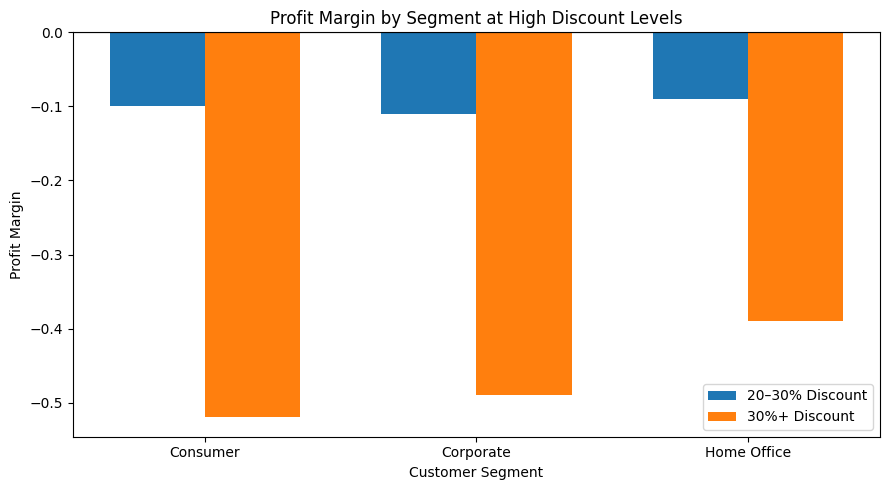

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
pivot = (
    segment_high_discount
    .pivot(index="segment", columns="discount_bucket", values="profit_margin")
)

segments = pivot.index
x = np.arange(len(segments))
width = 0.35

plt.figure(figsize=(9,5))

plt.bar(x - width/2, pivot["20–30%"], width, label="20–30% Discount")
plt.bar(x + width/2, pivot["30%+"], width, label="30%+ Discount")

plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(x, segments)
plt.ylabel("Profit Margin")
plt.xlabel("Customer Segment")
plt.title("Profit Margin by Segment at High Discount Levels")
plt.legend()

plt.tight_layout()
plt.show()

### Insight

Across all customer segments, discounts above 20% are structurally loss-making.

- At **30%+ discounts**, every segment shows severe margin collapse (–39% to –52%)
- Even the **20–30% range** remains consistently unprofitable across segments
- Consumer segment contributes the largest absolute losses due to higher volume

This indicates that profit leakage is driven by **pricing policy**, not customer mix.
Discounts above 20% should be tightly controlled regardless of segment.

## Q6. “Bad Deals” Identification

### Business Question

Which individual transactions (“deals”) are destroying value due to **heavy discounting combined with zero or negative profit**?

---

### Why this matters

While earlier analyses identified loss-making **buckets**, **segments**, and **subcategories**,  
profit leakage ultimately occurs at the **transaction (deal) level**.

This step isolates:
- Avoidable losses
- Pricing discipline failures
- Deals that should never have been approved

These represent the **highest-confidence, lowest-friction fixes**.

---

### Definition

A **Bad Deal** is defined as:

- **Discount ≥ 20%**
- **AND Profit ≤ 0**

This strict definition avoids ambiguity and ensures that only
clear pricing failures are flagged.

---

### Approach

- Filter transactions meeting the bad deal definition
- Quantify:
  - Number of bad deals
  - Revenue involved
  - Total profit destroyed
  - Share of overall sales and profit impact
- Identify where bad deals concentrate (subcategory / segment)

In [12]:
BAD_DISCOUNT = 0.20

bad_deals = orders[
    (orders["discount"] >= BAD_DISCOUNT) &
    (orders["profit"] <= 0)
].copy()

bad_deal_summary = pd.DataFrame({
    "Metric": [
        "Bad Deal Count",
        "Bad Deal Sales",
        "Bad Deal Profit",
        "Bad Deal % of Total Sales",
        "Bad Deal % of Total Profit"
    ],
    "Value": [
        bad_deals.shape[0],
        round(bad_deals["sales"].sum(), 2),
        round(bad_deals["profit"].sum(), 2),
        round(bad_deals["sales"].sum() * 100 / orders["sales"].sum(), 2),
        round(bad_deals["profit"].sum() * 100 / orders["profit"].sum(), 2)
    ]
})

bad_deal_summary

,Metric,Value
0,Bad Deal Count,1885.00
1,Bad Deal Sales,480935.14
2,Bad Deal Profit,-155773.31
3,Bad Deal % of Total Sales,20.94
4,Bad Deal % of Total Profit,-54.39


In [21]:
bad_deals[["order_id","subcategory","segment","discount","sales","profit","quantity"]].head(10)

,order_id,subcategory,segment,discount,sales,profit,quantity
3,US-2015-108966,Tables,Consumer,0.45,957.5775,-383.0310,5
14,US-2015-118983,Appliances,Home Office,0.80,68.8100,-123.8580,5
15,US-2015-118983,Binders,Home Office,0.80,2.5440,-3.8160,3
23,US-2017-156909,Chairs,Consumer,0.30,71.3720,-1.0196,2
27,US-2015-150630,Bookcases,Consumer,0.50,3083.4300,-1665.0522,7
28,US-2015-150630,Binders,Consumer,0.70,9.6180,-7.0532,2
32,US-2015-150630,Binders,Consumer,0.70,6.8580,-5.7150,6
36,CA-2016-117590,Furnishings,Corporate,0.60,190.9200,-147.9630,5
38,CA-2015-117415,Bookcases,Home Office,0.32,532.3992,-46.9764,3
39,CA-2015-117415,Chairs,Home Office,0.30,212.0580,-15.1470,3


In [22]:
#Bad Deals by subcategory
bad_deals_by_subcat = (
    bad_deals
    .groupby("subcategory", as_index=False)
    .agg(
        bad_deal_lines=("order_id", "count"),
        bad_deal_sales=("sales", "sum"),
        bad_deal_profit=("profit", "sum"),
        avg_discount=("discount", "mean")
    )
)

bad_deals_by_subcat["bad_deal_margin"] = (
    bad_deals_by_subcat["bad_deal_profit"] / bad_deals_by_subcat["bad_deal_sales"]
)

bad_deals_by_subcat = bad_deals_by_subcat.sort_values("bad_deal_profit").head(10)
bad_deals_by_subcat

,subcategory,bad_deal_lines,bad_deal_sales,bad_deal_profit,avg_discount,bad_deal_margin
2,Binders,613,36140.6130,-38510.4964,0.738010,-1.065574
11,Tables,205,105982.1990,-32412.1483,0.364634,-0.305826
7,Machines,44,72456.2530,-30118.6682,0.581818,-0.415681
3,Bookcases,94,42631.9028,-11823.5030,0.382340,-0.277339
4,Chairs,251,106072.6140,-9851.5669,0.262948,-0.092876
1,Appliances,67,3382.5340,-8629.6412,0.800000,-2.551236
8,Phones,136,35797.8400,-7530.6235,0.342647,-0.210365
6,Furnishings,176,14808.6200,-6490.9134,0.513636,-0.438320
9,Storage,162,38462.6400,-6426.3038,0.200000,-0.167079
10,Supplies,33,14067.1760,-3015.6219,0.200000,-0.214373


### Insight

Bad deals are a **major driver of profit leakage**, not a minor edge case.

- **1,885** transactions qualify as bad deals (**discount ≥ 20% and profit ≤ 0**)
- They contribute **~₹481K sales** (≈ **20.9%** of revenue)
- But they generate **~₹156K losses**, which is equivalent to **~54% of total net profit** in magnitude

**Where the damage concentrates**
Bad deals are concentrated in a few subcategories (e.g., **Binders, Tables, Machines, Bookcases**), indicating that profit leakage is driven by repeatable pricing failure modes — not random noise.

**Implication**
Eliminating or tightening controls on these deals is the **highest-confidence lever** to improve profitability without chasing more sales.

## Q7. Ineffective Discounting — High Discounts with Weak Volume Response

### Business Question

Are there subcategories where **heavy discounting fails to drive meaningful volume or sales**?

In other words:
- Are we giving large discounts
- Without getting proportional demand or revenue in return?

---

### Why this matters

Discounting is only justified if it achieves **one of two things**:
- Drives **volume growth**
- Enables **strategic customer acquisition**

If high discounts:
- Do **not** increase quantity sold
- Do **not** generate meaningful revenue uplift

Then they represent **pure margin destruction** with no compensating benefit.

This analysis isolates:
- Subcategories where discounting is **ineffective**
- Pricing behavior that should be **stopped entirely**, not “optimized”

---

### Definition of Ineffective Discounting

A subcategory is flagged as **ineffectively discounted** if:

- **Average discount ≥ 20%**
- **AND average quantity per order is low**
- **AND total profit is weak or negative**

This ensures we are not penalizing:
- Legitimate bulk-discount categories
- High-volume, low-margin strategies that still make sense

---

### Approach

- Aggregate data at the **subcategory level**
- Compute:
  - Total sales
  - Total profit
  - Average discount
  - Total quantity sold
  - Average quantity per order
- Focus on subcategories with:
  - High discount exposure
  - Weak volume response
- Identify candidates where discounting is **not economically justified**

In [15]:
subcat_metrics = orders.groupby('subcategory').agg(
    total_sales = ('sales','sum'),
    total_profit = ('profit','sum'),
    avg_discount = ('discount','mean'),
    total_quantity = ('quantity','sum'),
    order_count = ('order_id','nunique')
).reset_index()

subcat_metrics['avg_qty_per_order'] = (
    subcat_metrics['total_quantity'] / subcat_metrics['order_count']
)

subcat_high_discount = subcat_metrics[subcat_metrics['avg_discount'] >= 0.2]
subcat_high_discount.sort_values(by=['total_profit','avg_qty_per_order'])

,subcategory,total_sales,total_profit,avg_discount,total_quantity,order_count,avg_qty_per_order
16,Tables,206965.5320,-17725.4811,0.261285,1241,307,4.042345
4,Bookcases,114879.9963,-3472.5560,0.211140,868,224,3.875000
11,Machines,189238.6310,3384.7569,0.306087,440,112,3.928571
3,Binders,203412.7330,30221.7633,0.372292,5974,1316,4.539514


### Insight

High discounting does **not** consistently translate into higher order-level volume.

- Several subcategories maintain **average discounts ≥ 20%**
- Yet their **average quantity per order remains flat** (≈ 3–4 units)
- These same subcategories are **low-margin or loss-making**

This indicates **ineffective discounting**:
price reductions are not driving meaningful volume uplift but are directly eroding margins.

**Implication**
For these subcategories, discounting fails its primary justification (volume expansion) and should be **capped or approval-gated**, not used as a default lever.

## Q8. Is profit leakage concentrated in a small number of subcategories, or is it broadly distributed?

### Business Question

Is profit leakage driven by a **small number of subcategories** or spread broadly across the portfolio?

---

### Why this matters

If losses are **concentrated**, the business can:
- Fix a few problem areas
- Recover profit quickly
- Avoid blanket pricing changes

If losses are **widespread**, the issue is structural and requires:
- System-wide pricing controls
- Policy-level intervention

This distinction determines whether the solution is **surgical** or **systemic**.

---

### Approach

- Rank subcategories by total profit (worst to best)
- Isolate loss-making subcategories
- Measure:
  - Share of total losses from Top N subcategories
- Apply a **Pareto-style lens** to identify concentration

In [23]:
loss_subcats = subcategory_metrics[subcategory_metrics["total_profit"] < 0].copy()

# Convert negative profit into positive loss magnitude
loss_subcats["abs_loss"] = -loss_subcats["total_profit"]

# Total loss across all loss-making subcategories
total_loss_abs = loss_subcats["abs_loss"].sum()

# Share + cumulative share
loss_subcats = loss_subcats.sort_values("abs_loss", ascending=False)
loss_subcats["loss_share_pct"] = round(loss_subcats["abs_loss"] * 100 / total_loss_abs, 2)
loss_subcats["cum_loss_pct"] = loss_subcats["loss_share_pct"].cumsum()

loss_subcats[[
    "subcategory", "total_sales", "total_profit", "avg_discount",
    "abs_loss", "loss_share_pct", "cum_loss_pct"
]]

,subcategory,total_sales,total_profit,avg_discount,abs_loss,loss_share_pct,cum_loss_pct
16,Tables,206965.5320,-17725.4811,0.261285,17725.4811,79.18,79.18
4,Bookcases,114879.9963,-3472.5560,0.211140,3472.5560,15.51,94.69
15,Supplies,46673.5380,-1189.0995,0.076842,1189.0995,5.31,100.00


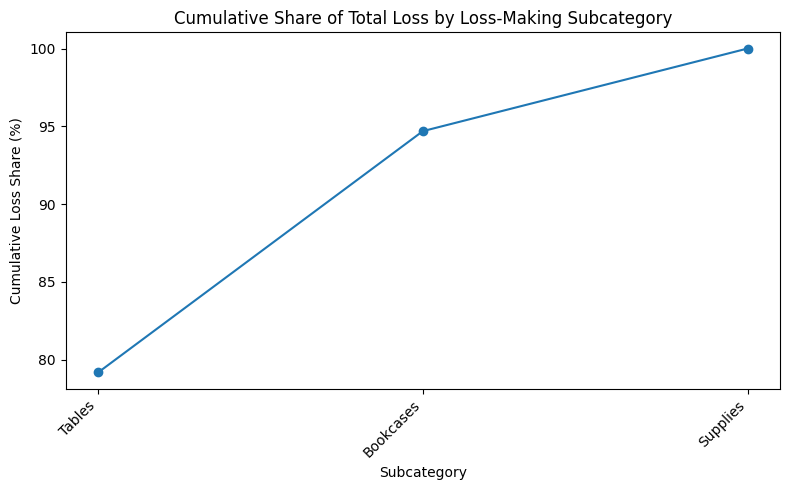

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(loss_subcats["subcategory"], loss_subcats["cum_loss_pct"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.title("Cumulative Share of Total Loss by Loss-Making Subcategory")
plt.ylabel("Cumulative Loss Share (%)")
plt.xlabel("Subcategory")
plt.tight_layout()
plt.show()

### Insight

Profit leakage is **highly concentrated**, not widespread.

- Only **3 subcategories** are loss-making overall
- The **Top 1–3 loss drivers account for ~100% of total losses**
- This confirms a **Pareto-style pattern**: fixing a small number of subcategories can recover most avoidable loss

**Implication**
Pricing intervention should be **surgical**:
cap discounts and enforce approvals only where leakage is proven, instead of applying blanket discount restrictions.

## Q9. Pricing Rules & Discount Controls

### Business Question

Based on observed profit leakage patterns, **what concrete pricing rules should be enforced** to prevent avoidable losses while preserving legitimate discount flexibility?

---

### Why this matters

The analysis so far shows that:

- Profit leakage is **not evenly distributed**
- Losses are **concentrated in specific discount ranges and subcategories**
- Discounts beyond certain thresholds are **consistently value-destructive**

At this stage, the objective shifts from diagnosis to **operational decision-making**.

Well-defined pricing rules help:
- Prevent repeat losses
- Reduce pricing approval noise
- Preserve flexibility where discounting is justified
- Convert analytics into enforceable controls

---

### Design Principles for Pricing Rules

Any recommended pricing rule must be:

- **Data-backed** — grounded in observed profit outcomes  
- **Targeted** — applied only where leakage is proven  
- **Actionable** — simple to enforce operationally  
- **Non-disruptive** — avoids blanket discount bans  

---

### Inputs Used

Pricing rules are derived from:

- Profit margin by discount bucket (Q2, Q3)
- Structural loss-making subcategories (Q4, Q8)
- Bad deal concentration (Q6)
- Volume response to discounting (Q7)

---

### Approach

- Identify discount thresholds beyond which profitability collapses
- Isolate subcategories responsible for disproportionate losses
- Propose:
  - Discount caps
  - Approval thresholds
  - Category-specific pricing restrictions

These rules are designed to **block known failure modes**, not hypothetical ones.

---

*(Pricing rule derivation and supporting tables follow below.)*

## Q10. Final Pricing & Discount Control Playbook

### Business Objective

Translate analytical findings into a **clear, enforceable pricing playbook** that:
- Stops known sources of profit leakage
- Preserves discount flexibility where it creates value
- Enables consistent decision-making across teams

This section consolidates all prior insights into **actionable rules**.

---

### Summary of Key Findings (Input to Playbook)

From the analysis:

- Discounts **above 20% are structurally loss-making** across segments
- Profit leakage is **highly concentrated** in a small set of subcategories
- A limited number of **“bad deals” (high discount + negative profit)** destroy a disproportionate share of profit
- High discounts **do not reliably drive volume** in several loss-making subcategories

These patterns are **stable and repeatable**, making them suitable for policy enforcement.

---

### Pricing Control Framework

The recommended pricing controls operate on **three levels**:

1. **Global discount guardrails**
2. **Subcategory-specific restrictions**
3. **Deal-level approval rules**

This layered approach avoids blanket bans while blocking proven failure modes.

---

### Recommended Pricing Rules

#### 1. Global Discount Guardrails

- **Standard discount cap:** 20%
- Discounts above 20% require:
  - Explicit justification
  - Manager-level approval
- Discounts above 30% should be **exception-only**, not routine

**Rationale:**  
Margins collapse consistently beyond 20%, regardless of segment.

---

#### 2. Subcategory-Specific Controls

For structurally loss-making subcategories (e.g. Tables, Bookcases, Supplies):

- Lower maximum discount thresholds (≤15%)
- Mandatory approval for any exception
- Periodic review of pricing or cost structure

**Rationale:**  
Losses are driven by **structural pricing weakness**, not temporary noise.

---

#### 3. Bad Deal Prevention Rules

Define and block “bad deals” at creation time:

- **Rule:**  
  - Discount ≥ 20%  
  - AND projected profit ≤ 0
- System should:
  - Block auto-approval
  - Require override with documented rationale

**Rationale:**  
These deals are unambiguously value-destructive and fully avoidable.

---

### Where Discount Flexibility Is Allowed

- Subcategories with:
  - Positive margins
  - Healthy volume response to discounting
- Growth-focused use cases:
  - Customer acquisition
  - Strategic account expansion
- Subject to:
  - Time-bound controls
  - Post-deal margin review

**Rationale:**  
Not all discounting is bad — only **undisciplined discounting** is.

---

### Final Playbook Summary

**Tighten**
- Discounts ≥20%
- Loss-making subcategories
- Negative-profit transactions

**Allow (with control)**
- Moderate discounts in healthy categories
- Growth-driven deals with margin monitoring

**Stop**
- Repeated approval of known bad deal patterns
- Blanket discounting without profitability checks

---

### Business Impact

This playbook enables:

- Immediate profit protection without revenue growth assumptions
- Fewer approval escalations through clear rules
- Consistent pricing discipline across teams
- High-confidence fixes with minimal operational disruption

## Results Snapshot

This section consolidates the most important numerical outcomes from the analysis into a single executive view.

The metrics below summarize:
- overall business performance
- scale of discount-driven profit leakage
- impact of structurally bad deals

These figures are intended for quick review and interview discussion.

In [25]:
# Results Snapshot — Executive Summary Metrics

overall_sales = orders["sales"].sum()
overall_profit = orders["profit"].sum()
overall_margin = overall_profit / overall_sales

high_discount_sales = high_discount_buckets["total_sales"].sum()
high_discount_profit = high_discount_buckets["total_profit"].sum()

snapshot = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Overall Profit Margin",
        "Sales from ≥20% Discount",
        "Profit (Loss) from ≥20% Discount",
        "Bad Deal Count",
        "Bad Deal % of Total Sales",
        "Bad Deal % of Total Profit"
    ],
    "Value": [
        f"{overall_sales:,.0f}",
        f"{overall_profit:,.0f}",
        f"{overall_margin:.2%}",
        f"{high_discount_sales * 100 / overall_sales:.2f}%",
        f"{high_discount_profit * 100 / overall_profit:.2f}%",
        bad_deals.shape[0],
        f"{bad_deals['sales'].sum() * 100 / overall_sales:.2f}%",
        f"{bad_deals['profit'].sum() * 100 / overall_profit:.2f}%"
    ]
})

snapshot

,Metric,Value
0,Total Sales,"2,297,201"
1,Total Profit,"286,397"
2,Overall Profit Margin,12.47%
3,Sales from ≥20% Discount,15.79%
4,Profit (Loss) from ≥20% Discount,-47.27%
5,Bad Deal Count,1885
6,Bad Deal % of Total Sales,20.94%
7,Bad Deal % of Total Profit,-54.39%


In [28]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/P1_customer_risk_revenue_intelligence.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/P1_customer_risk_revenue_intelligence.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 794220 bytes to /content/drive/MyDrive/Colab Notebooks/P1_customer_risk_revenue_intelligence.html
